# Problem

The input is a music track corrupted by an unwanted instrumental component. The goal is to study the frequency content of the signal, design a suitable low-pass filtering approach, and export a cleaner version of the audio while preserving as much of the original song as possible.


The workflow followed in this notebook is:

1. Inspect the corrupted audio using waveform, FFT magnitude, and power spectral density plots.
2. Use the observed frequency distribution to choose candidate cutoff frequencies.
3. Compare an ideal low-pass filter with a realizable Butterworth low-pass filter.
4. Use Bode and pole-zero plots to analyze the designed Butterworth filter.
5. Export the filtered audio for listening-based evaluation.


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import librosa
import librosa.display 
import IPython.display as ipd 
from IPython.display import Audio, display
from ipywidgets import interact, Dropdown, IntSlider, Layout
import seaborn as sns
from scipy.signal import butter, filtfilt

Matplotlib is building the font cache; this may take a moment.


## Signal Analysis

The first step is to load the corrupted audio file and inspect its basic properties, including sample count, sampling rate, duration, and waveform shape.

In [2]:
# Load the corrupted audio at its original sampling rate.
audio_signal,sampling_rate=librosa.load('../data/song_with_2piccolo.wav',sr=None)
ipd.Audio(audio_signal,rate=sampling_rate)


In [3]:

print(len(audio_signal))
print(f"Sample Rate: {sampling_rate} Hz")
print(f"Duration: {len(audio_signal) / sampling_rate:.2f} seconds")

720001
Sample Rate: 48000 Hz
Duration: 15.00 seconds


In [4]:
# Normalize amplitude for waveform visualization.
normalized_audio=audio_signal/np.max(np.abs(audio_signal))

### Waveform Analysis

The waveform provides a time-domain view of the corrupted signal. This helps verify that the audio has been loaded correctly and gives a first look at its amplitude variation over time.

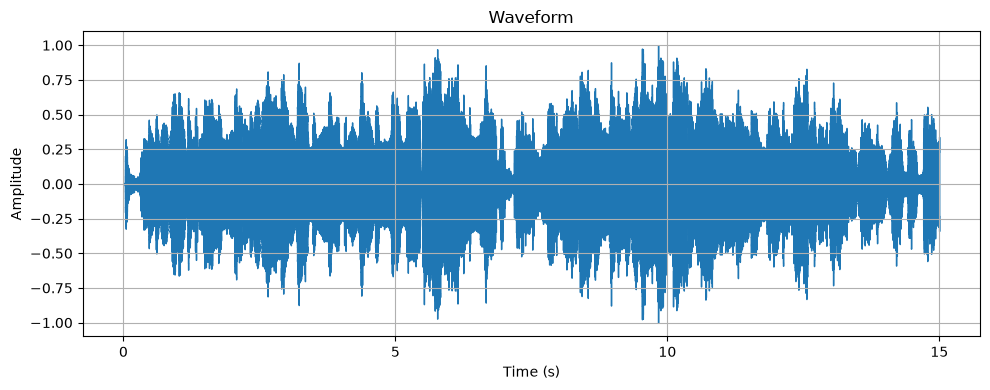

In [5]:
# Plot the normalized waveform in the time domain.
plt.figure(figsize=(10, 4))
librosa.display.waveshow(normalized_audio, sr=sampling_rate)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()

### Magnitude Spectrum

The FFT magnitude plot shows how strongly different frequency components are present in the signal. This is useful for identifying the frequency range where the unwanted instrumental component may be concentrated.


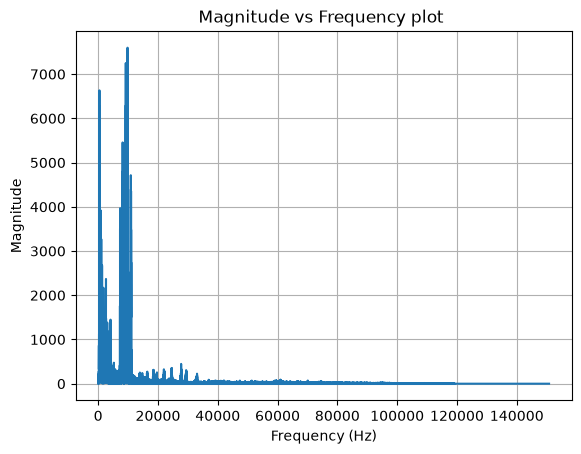

In [6]:
def plot_magnitude_spectrum(signal):
    # Use FFT to inspect the signal content in the frequency domain.
    spectrum=np.fft.fft(signal)
    frequencies=2*np.pi*np.fft.fftfreq(len(spectrum),1/sampling_rate)
    frequency_axis=frequencies[:len(frequencies)//2]
    magnitude_axis=np.abs(spectrum[:len(spectrum)//2])
    plt.plot(frequency_axis,magnitude_axis)
    plt.title("Magnitude vs Frequency plot ")
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()    

plot_magnitude_spectrum(audio_signal)

### Power Spectral Density

The power spectral density plot gives another frequency-domain view by showing how the signal power is distributed across frequencies.

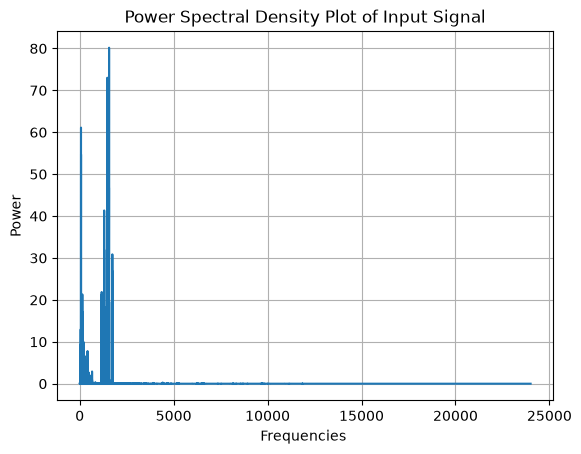

In [7]:
def plot_power_spectral_density(signal):
    # Estimate how signal power is distributed across frequencies.
    spectrum=np.fft.fft(signal)
    power=((np.abs(spectrum))**2)/len(spectrum)
    frequencies=np.fft.fftfreq(len(spectrum),1/sampling_rate)
    frequency_axis=frequencies[:len(frequencies)//2]
    power_axis=power[:len(power)//2]
    plt.plot(frequency_axis,power_axis)
    plt.title("Power Spectral Density Plot of Input Signal")
    plt.xlabel('Frequencies ')
    plt.ylabel('Power')
    plt.grid()
    plt.show()  
plot_power_spectral_density(audio_signal)
        

The dominant frequency content appears to be concentrated below approximately 2500 Hz. This observation motivates testing low-pass filters with cutoff frequencies in this range.

## Ideal Low-Pass Filter

Based on the frequency-domain analysis, the first filtering attempt uses an ideal low-pass response. Frequencies below the selected cutoff are retained, while frequencies above the cutoff are suppressed.

### Attempt 1: Ideal Low-Pass Filter

This section applies an ideal cutoff directly in the Fourier domain. The cutoff frequency is controlled interactively so the filtered audio can be evaluated by listening.

In [8]:
from scipy.io import wavfile

def save_audio(filename, signal, sampling_rate):
    # Convert the filtered signal to 16-bit PCM before writing a WAV file.
    real_signal = np.real(signal) 
    scaled_signal = np.int16(real_signal / np.max(np.abs(real_signal)) * 32767)
    wavfile.write(filename, sampling_rate, scaled_signal)


In [9]:
def plot_ideal_filter_response(filter_response,frequencies):
    # Add epsilon to avoid log10(0) in the ideal stopband.
    epsilon = 1e-12 
    frequency_axis=frequencies[:len(frequencies)//2]
    magnitude_axis=20*np.log10(np.abs(filter_response[:len(filter_response)//2])+epsilon)
    plt.plot(frequency_axis,magnitude_axis)
    plt.title("Magnitude dB vs Frequency plot ")
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude in dB ')
    plt.grid()
    plt.xlim([0, max(frequencies)])
    plt.show()    


In [10]:
def apply_ideal_lowpass_filter(cutoff): 
    spectrum=np.fft.fft(audio_signal)
    frequencies=np.fft.fftfreq(len(spectrum), 1/sampling_rate) 
    # Keep Fourier coefficients below the cutoff and suppress higher frequencies.
    ideal_filter_response=np.where( np.abs(frequencies)<=cutoff,1,0)
    low_frequency_spectrum=np.where(np.abs(frequencies)<=cutoff,spectrum,0)
    high_frequency_spectrum=np.where(np.abs(frequencies)>cutoff,spectrum,0)

    filtered_spectrum=low_frequency_spectrum
    filtered_audio=np.fft.ifft(filtered_spectrum) 
    plot_ideal_filter_response(ideal_filter_response,frequencies)
    save_audio("filtered_audio_lowpasfilter.wav",filtered_audio,sampling_rate )
    
    return ipd.Audio(filtered_audio,rate=sampling_rate)
    


In [11]:
# Interactive cutoff selection for listening-based evaluation.
sns.set(style="whitegrid")
interact(apply_ideal_lowpass_filter,
         cutoff=IntSlider(min=0,max=20000, step=10, value=1150, description=" cutoff frequency",layout=Layout(width='1000px'))
)

interactive(children=(IntSlider(value=1150, description=' cutoff frequency', layout=Layout(width='1000px'), ma…

<function __main__.apply_ideal_lowpass_filter(cutoff)>

## Limitations

A cutoff near 1150 Hz was selected after manually listening to the filtered output and identifying the point where the unwanted flute-like component became least audible.

The ideal low-pass filter is useful as a first experiment because it clearly shows the effect of removing all frequencies above the cutoff. However, it is not a practical realizable filter with a rational transfer function, so a pole-zero plot is not meaningful for this design. I kept this attempt in the notebook because it documents the reasoning path before moving to a realizable filter.

## Butterworth Filter

The second filtering attempt uses a Butterworth low-pass filter. Unlike the ideal filter, the Butterworth filter is realizable and can be analyzed using its transfer function, Bode response, and pole-zero plot.

In [12]:
from scipy.signal import freqz

In [13]:
# Plot the Butterworth transfer-function magnitude and phase response.
def plot_butterworth_response(numerator_coefficients,denominator_coefficients,sampling_rate ):
    angular_frequency,frequency_response= freqz( numerator_coefficients,denominator_coefficients,worN=8000)
    real_frequency=angular_frequency*sampling_rate/(2*np.pi)
    magnitude_db= 20*np.log10(np.abs(frequency_response)) 
    phase=np.angle(frequency_response)
    # mag plot 
    plt.title("Bode's Magnitude Plot of the transfer function")
    plt.plot(real_frequency,magnitude_db, label="Magnitude")
    plt.xlabel("Frequencies ")
    plt.ylabel("Magnitude in dB ")
    plt.grid()
    plt.legend()
    plt.show()

    # phase plot 
    plt.title("Phase Plot ")
    plt.plot(real_frequency, phase , label="Phase")
    plt.xlabel("frequencies")
    plt.ylabel("Phase")
    plt.grid()
    plt.legend()
    plt.show() 
    


In [14]:
def plot_pole_zero(numerator_coefficients,denominator_coefficients):
    # Roots of the numerator and denominator give zeros and poles.
    zeros=np.roots(numerator_coefficients)
    poles=np.roots(denominator_coefficients)
    plt.figure(figsize=(7,7))
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_artist(circle)

    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Zeros')
    plt.scatter(np.real(poles), np.imag(poles), marker='x', label='Poles')
    plt.xlabel('Real axis : sigma  ')
    plt.ylabel('Imaginary axis: jw')
    plt.title('Pole-Zero Plot')
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()

In [15]:
def apply_butterworth_lowpass_filter( signal, sampling_rate,cutoff,order):
    signal = np.asarray(signal).flatten()
    nyquist_freq=sampling_rate/2 
    normalized_cutoff=cutoff/(sampling_rate/2)
    # Design the low-pass Butterworth filter for the selected cutoff and order.
    numerator_coefficients,denominator_coefficients=butter(N=order, Wn=normalized_cutoff, btype='low')

    plot_butterworth_response(numerator_coefficients,denominator_coefficients,sampling_rate)
    plot_pole_zero(numerator_coefficients,denominator_coefficients)
    padlen = 3 * max(len(numerator_coefficients), len(denominator_coefficients))
    print(f"Signal length: {len(signal)}, Padlen needed: {padlen}")

    if len(signal) <= padlen:
        print("Warning: Signal too short for filtfilt! Switching to lfilter instead.")
        from scipy.signal import lfilter
        filtered_audio = lfilter(numerator_coefficients, denominator_coefficients, signal)
    else:
        # filtfilt applies the filter forward and backward to reduce phase distortion.
        filtered_audio = filtfilt(numerator_coefficients, denominator_coefficients, signal)
    save_audio("Butterworth_audio.wav",filtered_audio,sampling_rate)
    return ipd.Audio(filtered_audio, rate=sampling_rate)






In [16]:
from ipywidgets import fixed

In [17]:
# Interactive Butterworth filter controls for cutoff and order.
sns.set(style="whitegrid")
interact(apply_butterworth_lowpass_filter,
         signal=fixed(audio_signal),
         sampling_rate=fixed(sampling_rate),
         cutoff=IntSlider(min=20,max=20000, step=10, value=1150, description=" cutoff frequency",layout=Layout(width='1000px')),
         order=IntSlider(min=1, max=12,step=1, value=4, description="Order of the butterworth Filter" )
)

interactive(children=(IntSlider(value=1150, description=' cutoff frequency', layout=Layout(width='1000px'), ma…

<function __main__.apply_butterworth_lowpass_filter(signal, sampling_rate, cutoff, order)>

## Results

The notebook compares two filtering approaches. The ideal low-pass filter provides an intuitive frequency-domain baseline, while the Butterworth filter provides a smoother and practically realizable design. The interactive controls allow the cutoff frequency and filter order to be adjusted while listening to the filtered output.

## Conclusion

The corrupted track was analyzed in both time and frequency domains, then filtered using ideal and Butterworth low-pass designs. The Butterworth filter is the stronger final choice because it is realizable, supports transfer-function analysis, and gives a smoother practical response for attenuating the unwanted high-frequency component.

- Analyzed the corrupted audio using waveform, FFT magnitude, and power spectral density plots.
- Used the observed frequency content to guide low-pass filter design.
- Compared an ideal low-pass filter with a Butterworth low-pass filter.
- Selected the Butterworth approach because it has a realizable transfer function and supports Bode and pole-zero analysis.
- Exported filtered audio outputs for listening-based evaluation.


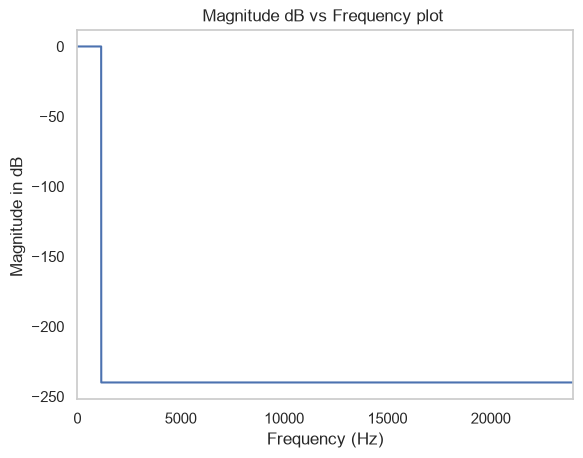

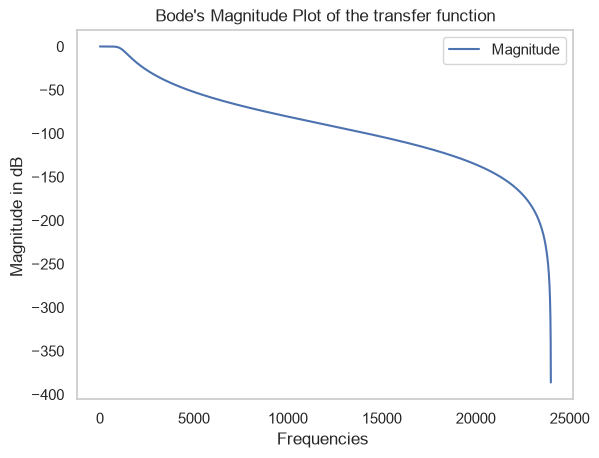

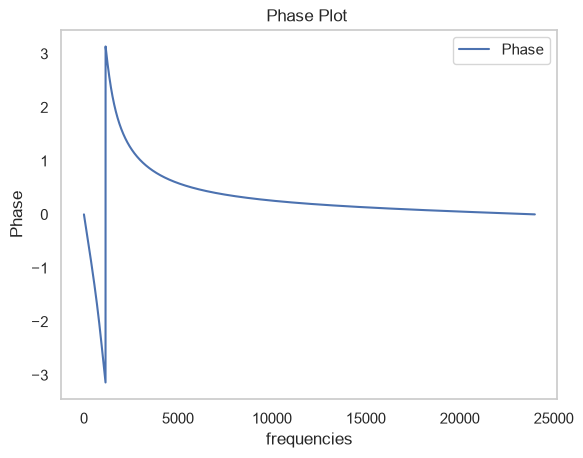

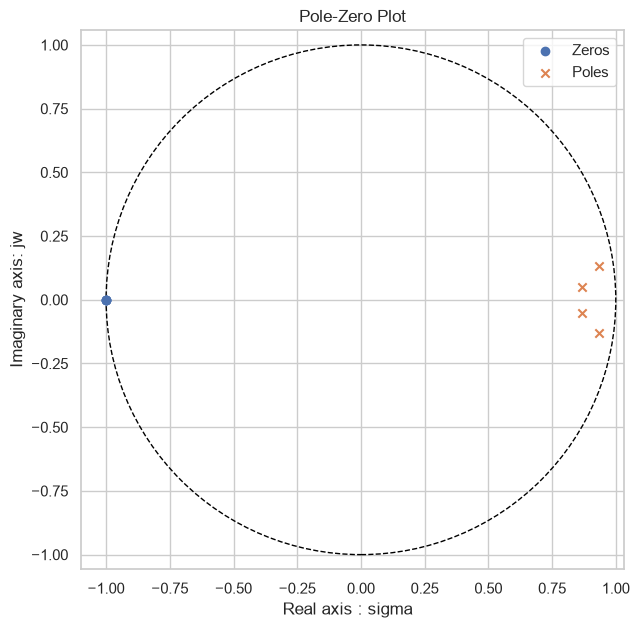

Signal length: 720001, Padlen needed: 15


In [18]:
# Static example for GitHub portfolio rendering - Ideal Lowpass\n
apply_ideal_lowpass_filter(cutoff=1150)
# Static example for GitHub portfolio rendering - Butterworth\n
apply_butterworth_lowpass_filter(signal=audio_signal, sampling_rate=sampling_rate, cutoff=1150, order=4)